# Unsupervised Learning: Clustering

C:\Users\ADMIN\anaconda3\envs\ML_course-2\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\ML_course-2\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


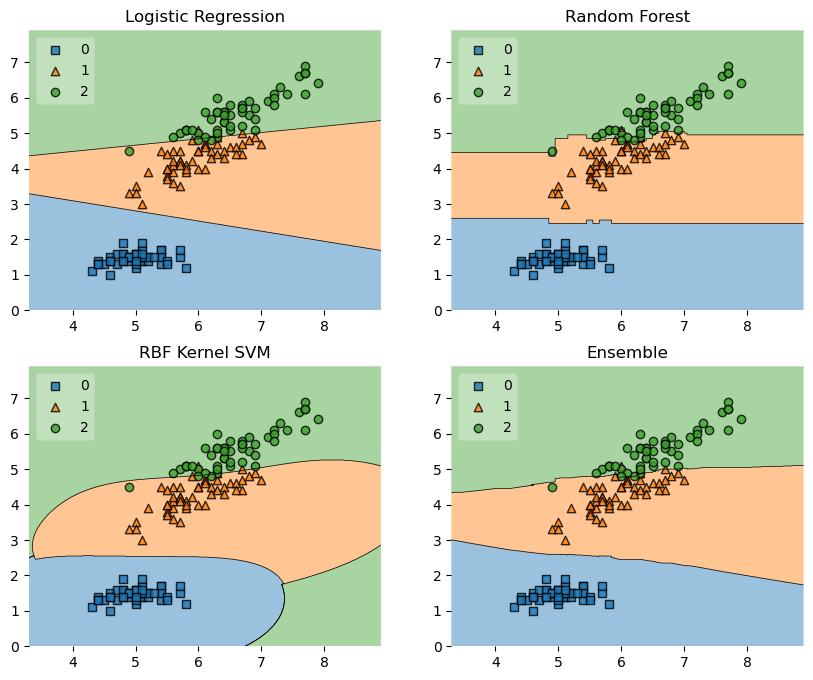

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from sklearn.svm import SVC
from mlxtend.data import iris_data
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from mlxtend.plotting import plot_decision_regions

#Initializing classifiers.
clf1 = LogisticRegression(random_state=0,solver='lbfgs',multi_class='auto')
clf2 = RandomForestClassifier(random_state=0,n_estimators=100)
clf3 = SVC(random_state=0,probability=True,gamma='auto')
eclf = EnsembleVoteClassifier(clfs=[clf1, clf2, clf3],weights=[2,1,1],
                              voting='soft')

#Loading some example data
X,y=iris_data()
X=X[:,[0,2]]

#plotting Decision Regions:
gs=gridspec.GridSpec(2,2)
fig=plt.figure(figsize=(10,8))

for clf,lab,grd in zip([clf1, clf2, clf3,eclf],
                       ['Logistic Regression','Random Forest','RBF Kernel SVM','Ensemble'],
                       itertools.product([0,1],repeat=2)):
    clf.fit(X,y)
    ax=plt.subplot(gs[grd[0],grd[1]])
    fig=plot_decision_regions(X=X,y=y,clf=clf,legend=2)
    plt.title(lab)
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set()

In [5]:
from  sklearn.datasets import make_blobs

In [6]:
X,y=make_blobs(n_samples=600,centers=5,
               cluster_std=0.60,random_state=42)

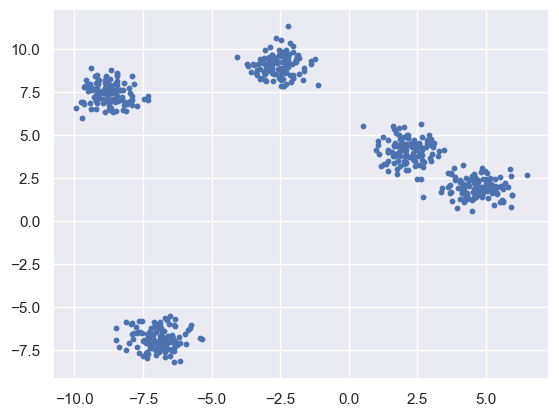

In [7]:
plt.scatter(X[:,0],X[:,1],s=10)

In [8]:
from scipy.cluster.hierarchy import ward,dendrogram,linkage
np.set_printoptions(precision=4,suppress=True)

In [9]:
distance=linkage(X,'ward')

### Dendrogram

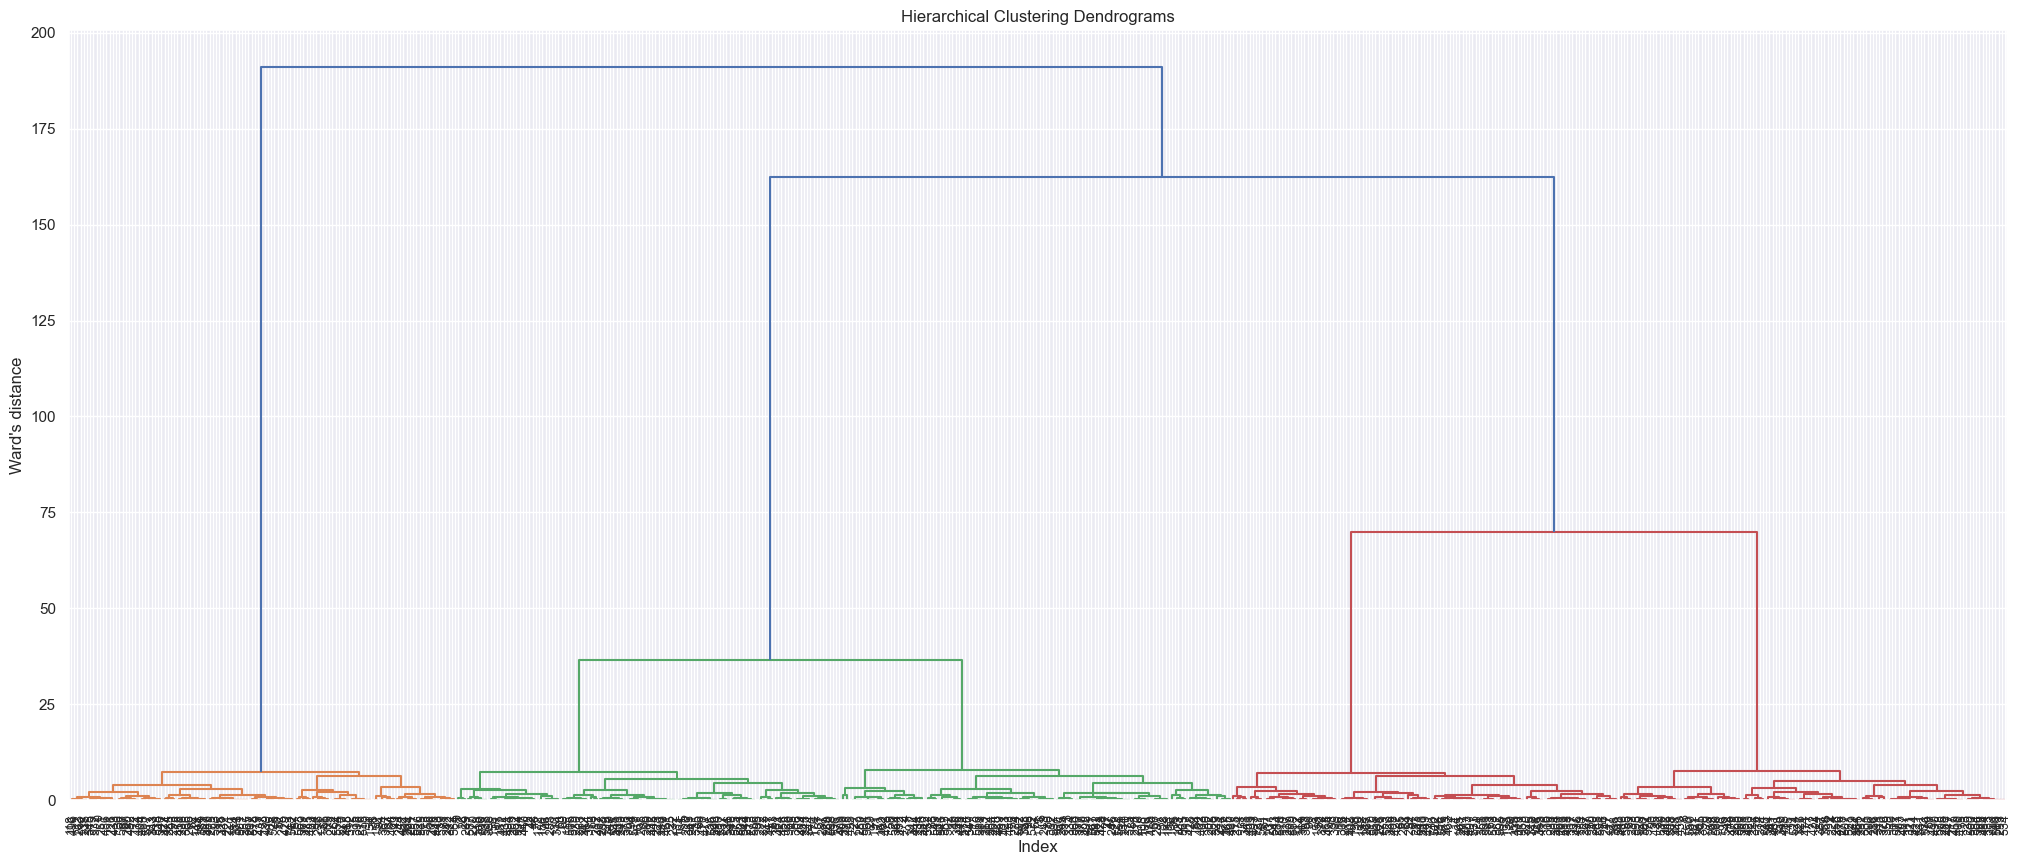

In [10]:
plt.figure(figsize=(25,10))
plt.title('Hierarchical Clustering Dendrograms')
plt.xlabel('Index')
plt.ylabel("Ward's distance")
dendrogram(distance,
           leaf_rotation=90.,
           leaf_font_size=9.,)
plt.show()

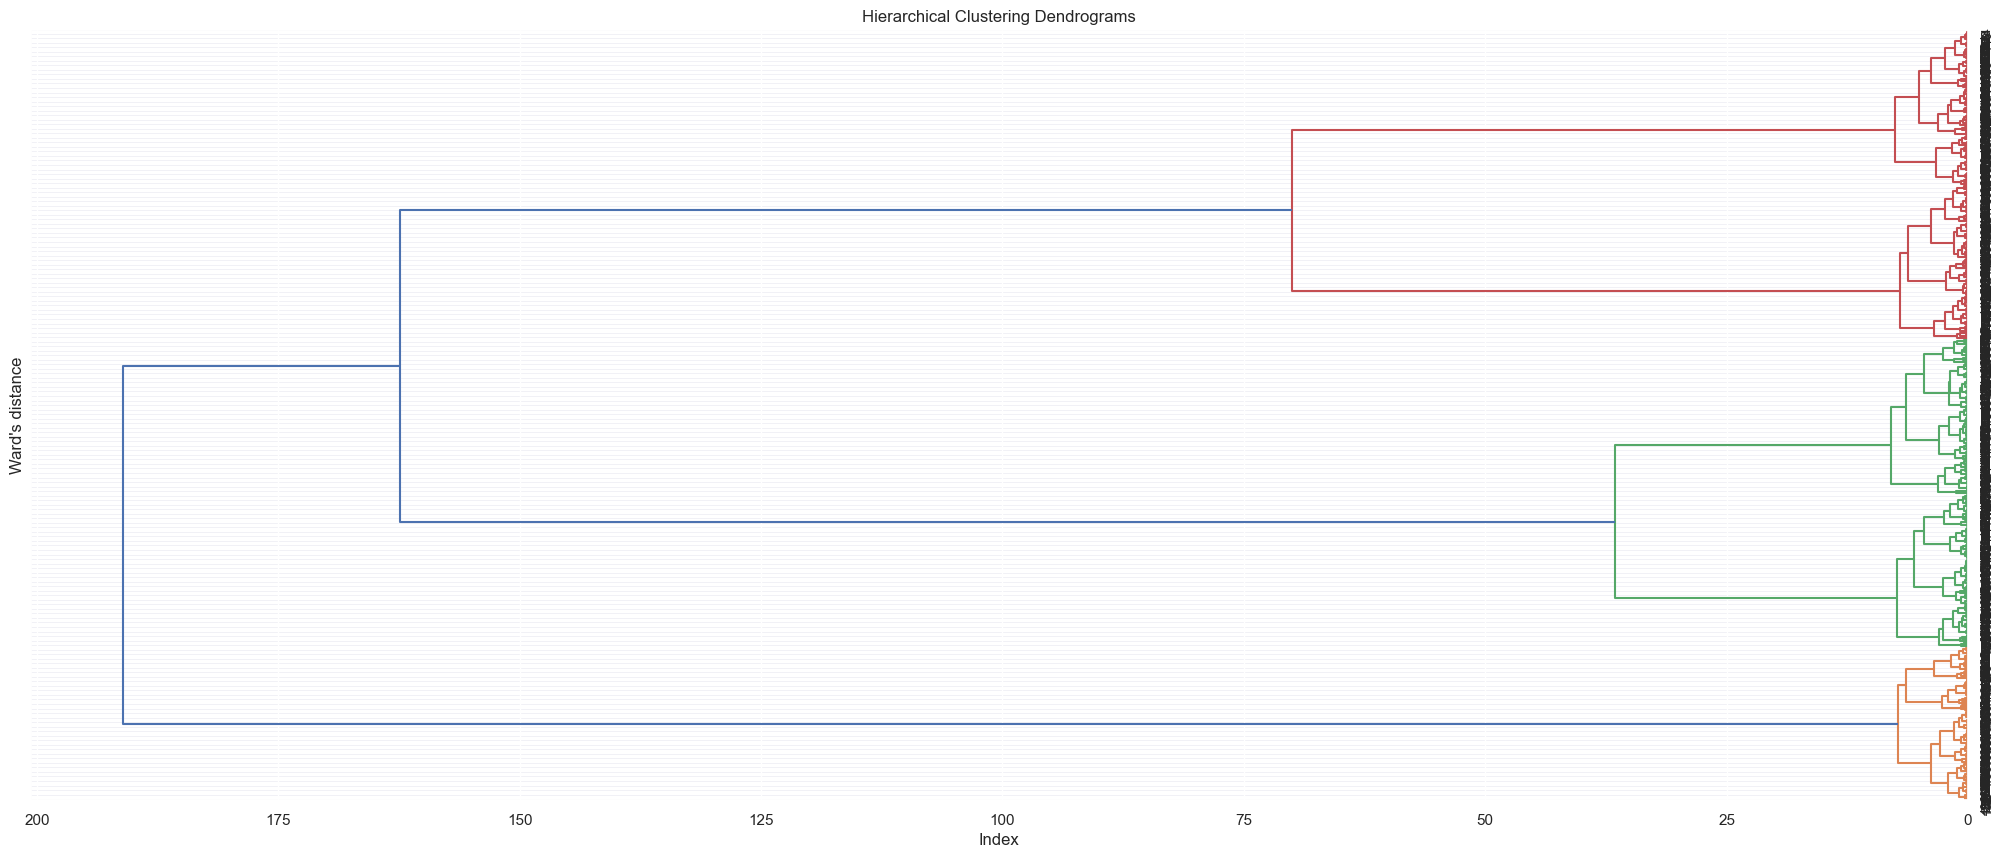

In [11]:
plt.figure(figsize=(25,10))
plt.title('Hierarchical Clustering Dendrograms')
plt.xlabel('Index')
plt.ylabel("Ward's distance")
dendrogram(distance,orientation='left',
           leaf_rotation=90.,
           leaf_font_size=9.,)
plt.show()

### Truncating Dendrogram

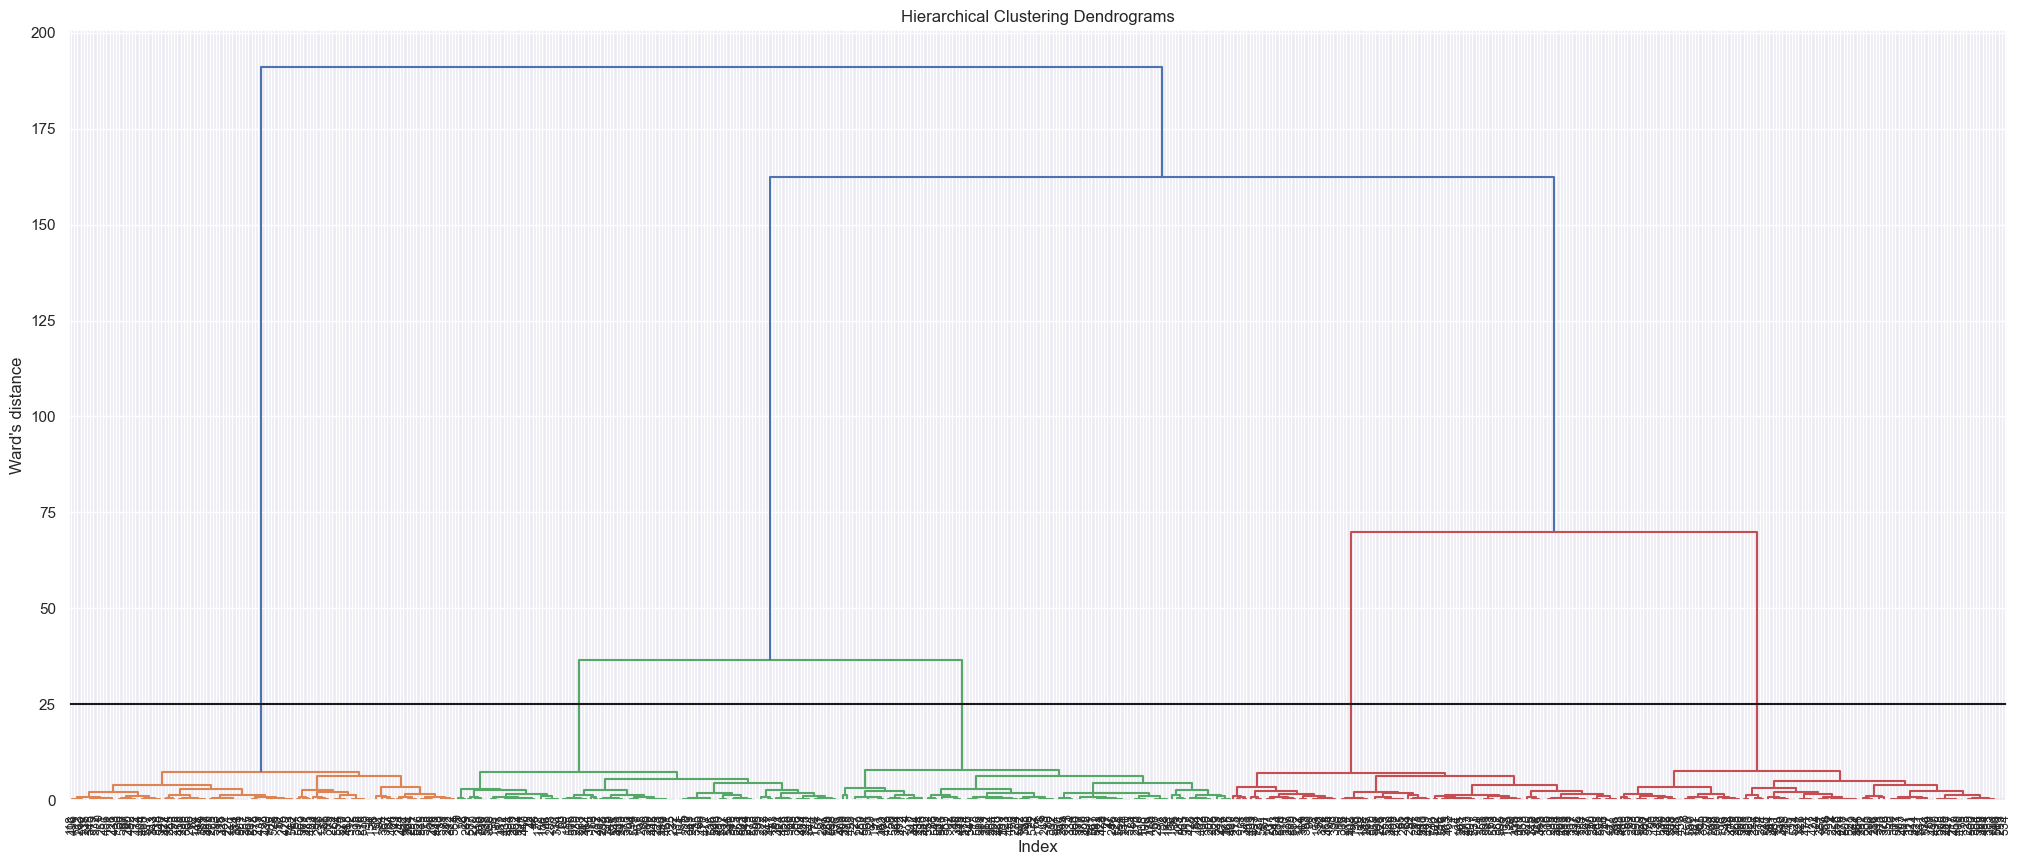

In [12]:
plt.figure(figsize=(25,10))
plt.title('Hierarchical Clustering Dendrograms')
plt.xlabel('Index')
plt.ylabel("Ward's distance")
dendrogram(distance,
           leaf_rotation=90.,
           leaf_font_size=9.,)
plt.axhline(25,c='k')
plt.show()

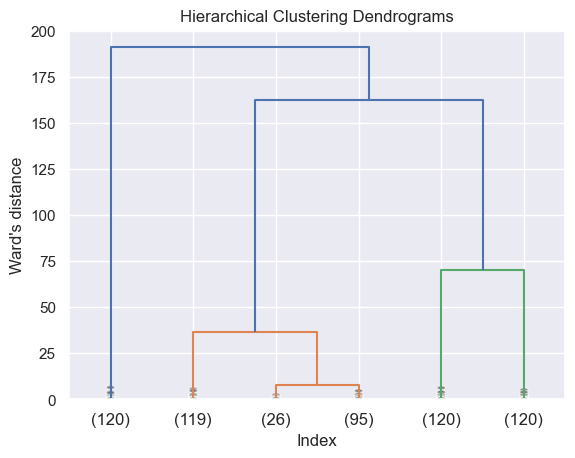

In [13]:
plt.title('Hierarchical Clustering Dendrograms')
plt.xlabel('Index')
plt.ylabel("Ward's distance")
dendrogram(distance,truncate_mode='lastp',
           p=6,show_contracted=True,
           leaf_rotation=0.,
           leaf_font_size=12.,)
plt.show()

### Retrieve the Clusters

In [14]:
from scipy.cluster.hierarchy import fcluster
max_d=25
clusters=fcluster(distance,max_d,criterion='distance')
clusters

array([1, 1, 5, 3, 3, 2, 3, 4, 5, 2, 1, 5, 2, 4, 4, 1, 4, 3, 5, 3, 4, 3,
       2, 5, 5, 2, 2, 3, 3, 3, 1, 4, 5, 1, 1, 3, 2, 2, 1, 4, 3, 2, 2, 1,
       1, 2, 2, 3, 5, 3, 4, 2, 1, 2, 4, 3, 4, 1, 1, 3, 2, 4, 1, 4, 3, 2,
       1, 3, 2, 2, 5, 3, 1, 3, 5, 1, 4, 5, 1, 5, 3, 1, 1, 3, 3, 4, 3, 1,
       5, 5, 5, 1, 4, 4, 2, 2, 4, 4, 3, 1, 3, 5, 4, 5, 5, 1, 3, 4, 3, 4,
       4, 5, 4, 3, 5, 2, 5, 4, 1, 1, 5, 5, 3, 3, 2, 4, 4, 4, 5, 2, 2, 1,
       1, 4, 3, 4, 2, 2, 2, 1, 5, 2, 2, 1, 4, 5, 4, 1, 2, 1, 5, 2, 1, 4,
       1, 4, 2, 3, 5, 5, 3, 3, 3, 4, 2, 4, 4, 3, 4, 1, 2, 2, 2, 4, 4, 3,
       2, 3, 4, 3, 2, 5, 3, 1, 1, 2, 4, 2, 5, 5, 2, 3, 4, 3, 1, 2, 5, 3,
       4, 2, 5, 4, 3, 5, 3, 5, 1, 1, 2, 2, 3, 3, 2, 3, 4, 1, 1, 5, 4, 2,
       2, 1, 5, 2, 5, 4, 1, 4, 3, 5, 2, 4, 2, 5, 3, 1, 1, 4, 4, 5, 4, 2,
       1, 3, 1, 3, 3, 4, 2, 2, 2, 1, 4, 5, 2, 3, 5, 1, 2, 2, 2, 4, 3, 1,
       3, 5, 1, 4, 4, 2, 2, 2, 1, 2, 3, 1, 3, 4, 5, 1, 5, 4, 5, 4, 4, 1,
       5, 2, 2, 3, 1, 1, 2, 1, 1, 5, 1, 3, 5, 4, 4,

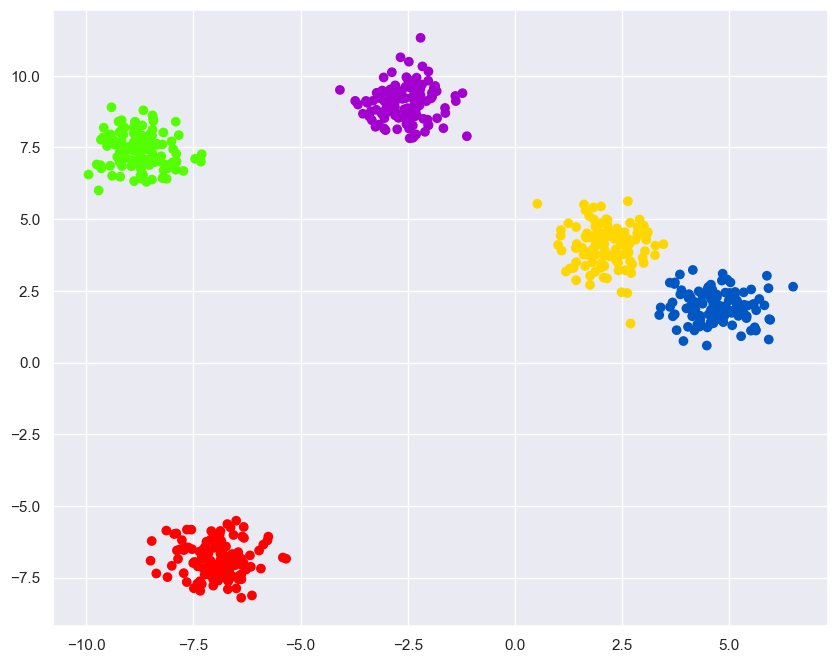

In [15]:
plt.figure(figsize=(10,8))
plt.scatter(X[:,0],X[:,1],c=clusters,cmap='prism')

### By Clusters

In [16]:
k=5
clusters=fcluster(distance,k,criterion='maxclust')

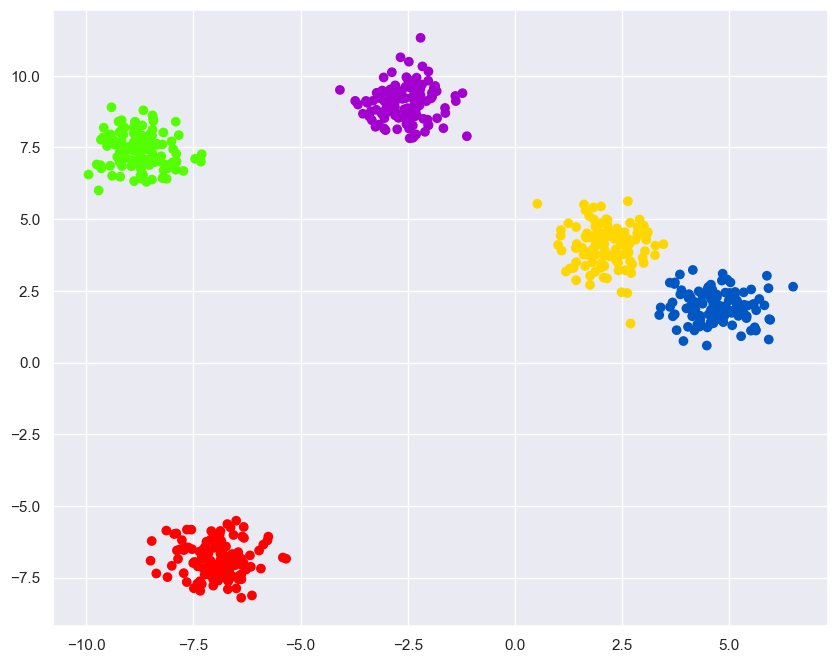

In [17]:
plt.figure(figsize=(10,8))
plt.scatter(X[:,0],X[:,1],c=clusters,cmap='prism')

## K-Means Clustering

In [18]:
from sklearn.cluster import KMeans

In [19]:
kmeans=KMeans(n_clusters=9)
kmeans.fit(X)

,n_clusters,9
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
y_kmeans=kmeans.predict(X)

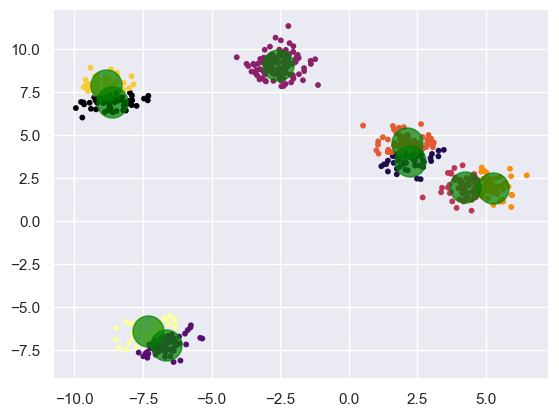

In [21]:
plt.scatter(X[:,0],X[:,1],c=y_kmeans,s=10,cmap='inferno')

centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c='green',s=500,alpha=0.7)

C:\Users\ADMIN\anaconda3\envs\ML_course-2\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

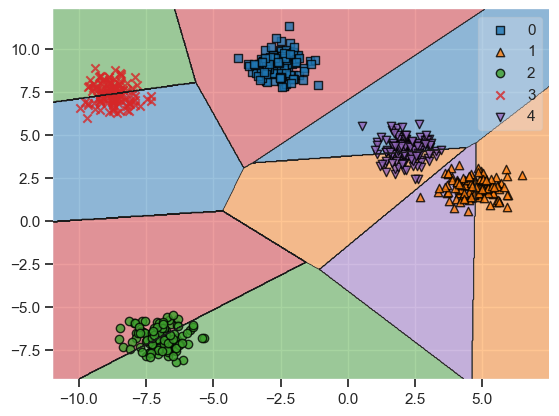

In [22]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y,clf=kmeans)

## Elbow Method

In [23]:
kmeans.inertia_

287.2292576321689

In [24]:
sse_=[]
for k in range(1,8):
    kmeans=KMeans(n_clusters=k).fit(X)
    sse_.append([k,kmeans.inertia_])

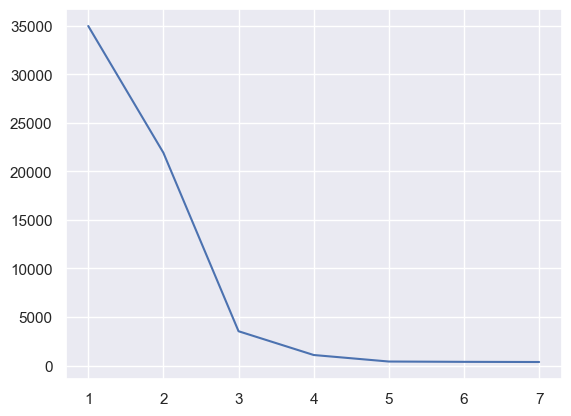

In [25]:
plt.plot(pd.DataFrame(sse_)[0],pd.DataFrame(sse_)[1])

The sharp drop is natural choice it starts from 3,4,5 and etc.

## Silhouette Analysis

In [26]:
from sklearn.metrics import silhouette_score

In [27]:
sse_=[]
for k in range(2,8):
    kmeans=KMeans(n_clusters=k).fit(X)
    sse_.append([k,silhouette_score(X,kmeans.labels_)])

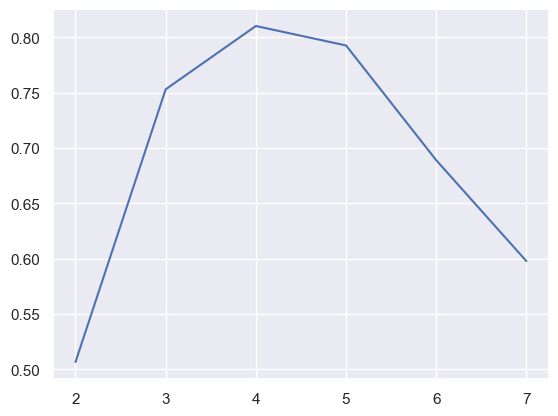

In [28]:
plt.plot(pd.DataFrame(sse_)[0],pd.DataFrame(sse_)[1])

## Mean shift

In [29]:
from sklearn.cluster import MeanShift,estimate_bandwidth

In [30]:
from itertools import cycle

In [31]:
bandwidth_X=estimate_bandwidth(X,quantile=0.1,n_samples=len(X))

In [32]:
meanshift_model=MeanShift(bandwidth=bandwidth_X,bin_seeding=True)
meanshift_model.fit(X)

,bandwidth,np.float64(0.9946702350329211)
,seeds,None
,bin_seeding,True
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


In [33]:
cluster_centers=meanshift_model.cluster_centers_

In [34]:
print("\nCenters of Clusters:\n",cluster_centers)


Centers of Clusters:
 [[-2.6733  8.9994]
 [ 4.6837  1.9518]
 [-8.789   7.4687]
 [ 2.2375  4.1844]
 [-6.9235 -7.0323]]


In [35]:
labels=meanshift_model.labels_
num_clusters=len(np.unique(labels))
print("\nNumber of clusters in input data=",num_clusters)


Number of clusters in input data= 5


Text(0.5, 1.0, 'Clusters')

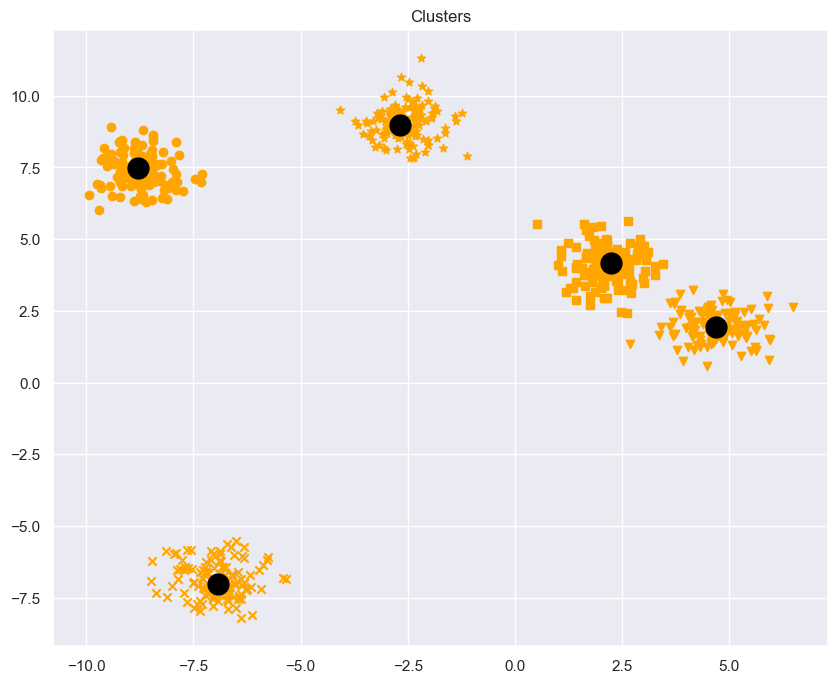

In [36]:
plt.figure(figsize=(10,8))
markers='*vosx'
for i, marker in zip(range(num_clusters),markers):
    plt.scatter(X[labels==i,0],X[labels==i,1],marker=marker,color='orange')
    cluster_center=cluster_centers[i]
    plt.plot(cluster_center[0],cluster_center[1],marker='o',
             markerfacecolor='black',markeredgecolor='black',
             markersize=15)
plt.title('Clusters')